# Cancer Type Classification Performance Analysis

This notebook analyzes the performance of different models on cancer type classification tasks.

**Models analyzed:**
- GDD-ENS
- GPT-5
- GPT-4o
- o3-mini
- MedGemma
- Qwen3
- DeepSeek
- Claude Sonnet 3.7

**Metrics calculated:**
- Accuracy
- F1 Score (weighted)
- Precision (weighted)
- Recall (weighted)

In [1]:
# Cell 0: Imports and Utility Functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Optional, Dict, Tuple
import os
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# # Set style
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette("husl")
from matplotlib import font_manager, rcParams
from matplotlib.lines import Line2D

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"
# Utility functions
def read_tsv_skip_comments(path: str) -> pd.DataFrame:
    """
    Read a TSV file, skipping lines that start with #.
    """
    return pd.read_csv(path, sep="\t", comment="#", dtype=str, low_memory=False)

def pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """
    Case-insensitive column selection.
    Returns the first matching column name from candidates, or None if not found.
    """
    cols_lower = {c.lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in cols_lower:
            return cols_lower[candidate.lower()]
    return None

print("✓ Imports and utility functions loaded")

✓ Imports and utility functions loaded


In [2]:
# Cell 1: Visualization Functions

def create_model_boxplot_with_dots(
    metrics_df,
    metric_col='accuracy',
    model_col='model',
    cancer_type_col='cancer_type',
    models_to_include=None,
    model_display_names=None,
    model_colors=None,
    figsize=(12, 8),
    y_label=None,
    title=None,
    y_lim=None,
    fontsize=14,
    dot_alpha=0.6,
    dot_size=80,
    jitter_strength=0.2
):
    """
    Create a box plot where x-axis is each model and y-axis is the distribution
    of stratified cancer type metrics. Overlays individual cancer type dots.
    """
    # Default display names and colors
    default_display_names = {
        'GDD-ENS': 'GDD-ENS',
        'gpt-5': 'GPT-5',
        'gpt-4o': 'GPT-4o',
        'o3-mini': 'o3-mini',
        'medgemma': 'MedGemma-27B',
        'qwen3': 'Qwen3-30B',
        'deepseek': 'DeepSeek-Distill-32B',
        'claude-sonnet-37': 'Claude-Sonnet-3.7'
    }

    default_colors = {
        'GDD-ENS': '#000000',
        'claude-sonnet-37': '#3232a8',
        'gpt-5': '#f97316',
        'gpt-4o': '#fb923c',
        'o3-mini': '#ea580c',
        'medgemma': '#10b981',
        'qwen3': '#8b5cf6',
        'deepseek': '#ffb343'
    }

    if model_display_names is None:
        model_display_names = default_display_names
    if model_colors is None:
        model_colors = default_colors

    # Filter and sort data
    df = metrics_df.copy()
    if models_to_include is not None:
        df = df[df[model_col].isin(models_to_include)]
    else:
        models_to_include = df[model_col].unique().tolist()

    df[model_col] = pd.Categorical(df[model_col], categories=models_to_include, ordered=True)
    df = df.sort_values(model_col)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    # Prepare data for box plots
    data_by_model = [df[df[model_col] == model][metric_col].dropna().values
                     for model in models_to_include]

    positions = np.arange(len(models_to_include))

    # Create box plots
    bp = ax.boxplot(
        data_by_model,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='darkred', linewidth=3),
        boxprops=dict(alpha=0.7),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2)
    )

    # Color boxes
    for patch, model in zip(bp['boxes'], models_to_include):
        color = model_colors.get(model, '#6b7280')
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(2)

    # Add jittered dots for individual cancer types
    np.random.seed(42)
    for i, model in enumerate(models_to_include):
        model_data = df[df[model_col] == model]
        y_values = model_data[metric_col].values
        jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(y_values))
        x_values = np.ones(len(y_values)) * i + jitter

        color = model_colors.get(model, '#6b7280')
        ax.scatter(
            x_values, y_values,
            alpha=dot_alpha,
            s=dot_size,
            color=color,
            edgecolors='white',
            linewidth=1,
            zorder=3
        )

    # Formatting
    ax.set_xticks(positions)
    display_labels = [model_display_names.get(m, m) for m in models_to_include]
    ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=fontsize)

    if y_label is None:
        y_label = metric_col.replace('_', ' ').title()
        if metric_col == 'accuracy':
            y_label += ' (%)'
    ax.set_ylabel(y_label, fontsize=fontsize + 2, fontweight='bold')

    if title is None:
        title = f'{metric_col.replace("_", " ").title()} Distribution Across Cancer Types'
    ax.set_title(title, fontsize=fontsize + 4, fontweight='bold', pad=20)

    if y_lim is not None:
        ax.set_ylim(y_lim)

    ax.tick_params(axis='y', labelsize=fontsize)
    ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

    plt.tight_layout()
    return fig

print("✓ Visualization functions loaded")

✓ Visualization functions loaded


In [3]:
# Cell 2: Configuration

# Base directory containing model outputs
BASE_RESULTS_DIR = "/data1/morrisq/yuj13/llm_genomics/genie_output"

# Models to analyze
MODEL_NAMES = [
    "GDD-ENS",
    "gpt-5", 
    "gpt-4o", 
    "o3-mini", 
    "medgemma", 
    "qwen3",
    "qwen3-vl-235b-a22b",
    "deepseek",
    "deepseek-r1",
    "claude-sonnet-37",
    "claude-sonnet-45",
    "claude-opus-45"
]

# Output directory
OUTPUT_DIR = "/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Parameters
MIN_SAMPLES_PER_CANCER = 10  # Minimum samples per cancer type for analysis
TOP_N = 15  # Top N cancer types to display in plots

print(f"✓ Configuration loaded")
print(f"  Base directory: {BASE_RESULTS_DIR}")
print(f"  Models: {', '.join(MODEL_NAMES)}")
print(f"  Output directory: {OUTPUT_DIR}")

✓ Configuration loaded
  Base directory: /data1/morrisq/yuj13/llm_genomics/genie_output
  Models: GDD-ENS, gpt-5, gpt-4o, o3-mini, medgemma, qwen3, qwen3-vl-235b-a22b, deepseek, deepseek-r1, claude-sonnet-37, claude-sonnet-45, claude-opus-45
  Output directory: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification


In [4]:
# Cell 3: Data Loading Functions

def load_model_predictions(model_dir: str, model_name: str) -> pd.DataFrame:
    """
    Load all prediction CSV files for a given model.
    Combines MSK and non-MSK batches.
    
    Handles different column naming conventions:
    - Standard: prediction1, prob1, prediction2, prob2, ground_truth
    - GDD-ENS: Pred1, Conf1, Pred2, Conf2, Cancer_Type
    
    Returns DataFrame with columns:
    - SAMPLE_ID
    - ground_truth
    - {model_name}_pred (top prediction)
    - {model_name}_prob (top prediction probability)
    """
    model_path = Path(model_dir)
    
    all_dfs = []
    
    # Load MSK validation data
    msk_path = model_path / "filtered_batch_msk" / "msk_validation.csv"
    if msk_path.exists():
        df_msk = pd.read_csv(msk_path)
        all_dfs.append(df_msk)
        print(f"  Loaded MSK validation: {len(df_msk)} samples")
    
    # For GDD-ENS, also check for batch files in filtered_batch_msk
    if model_name == "GDD-ENS":
        msk_batch_dir = model_path / "filtered_batch_msk"
        if msk_batch_dir.exists():
            msk_batch_files = sorted(msk_batch_dir.glob("batch*.csv"))
            for batch_file in msk_batch_files:
                df_batch = pd.read_csv(batch_file)
                all_dfs.append(df_batch)
            if msk_batch_files:
                print(f"  Loaded {len(msk_batch_files)} MSK batch files")
    
    # Load non-MSK batch files
    non_msk_dir = model_path / "filtered_batch_non_msk"
    if non_msk_dir.exists():
        batch_files = sorted(non_msk_dir.glob("batch*.csv"))
        for batch_file in batch_files:
            df_batch = pd.read_csv(batch_file)
            all_dfs.append(df_batch)
        if batch_files:
            print(f"  Loaded {len(batch_files)} non-MSK batch files")
    
    if not all_dfs:
        print(f"  WARNING: No data found for {model_name}")
        return pd.DataFrame()
    
    # Concatenate all data
    df = pd.concat(all_dfs, ignore_index=True)
    
    # Normalize column names based on model
    # GDD-ENS uses: Pred1, Conf1, Pred2, Conf2, Cancer_Type
    # Others use: prediction1, prob1, prediction2, prob2, ground_truth
    if 'Pred1' in df.columns:
        # GDD-ENS format
        df = df.rename(columns={
            'Pred1': 'prediction1',
            'Conf1': 'prob1',
            'Pred2': 'prediction2',
            'Conf2': 'prob2',
            'Cancer_Type': 'ground_truth'
        })
    
    # Keep only necessary columns (only SAMPLE_ID, prediction1, prob1, ground_truth)
    # We don't need prediction2/prob2 for the main analysis
    columns_to_keep = ['SAMPLE_ID', 'prediction1', 'prob1', 'prediction2', 'ground_truth']
    # Only keep columns that exist
    columns_to_keep = [col for col in columns_to_keep if col in df.columns]
    df = df[columns_to_keep]
    
    # Deduplicate by SAMPLE_ID (keep first occurrence)
    df = df.drop_duplicates(subset=['SAMPLE_ID'], keep='first')
    
    # Rename prediction columns to be model-specific
    df = df.rename(columns={
        'prediction1': f'{model_name}_pred',
        'prob1': f'{model_name}_prob',
        'prediction2': f'{model_name}_pred2'
    })
    
    print(f"  Total unique samples: {len(df)}")
    
    return df

def load_all_model_predictions(model_names: List[str], base_dir: str) -> pd.DataFrame:
    """
    Load predictions from all models and merge them.
    
    Returns merged DataFrame with:
    - SAMPLE_ID
    - ground_truth (cancer type)
    - {model_name}_pred (prediction for each model)
    - {model_name}_prob (probability for each model)
    """
    print("Loading model predictions...\\n")
    
    dfs = []
    for model_name in model_names:
        print(f"Loading {model_name}:")
        model_dir = os.path.join(base_dir, model_name)
        df = load_model_predictions(model_dir, model_name)
        if not df.empty:
            dfs.append(df)
        print()
    
    if not dfs:
        raise ValueError("No data loaded from any model!")
    
    # Merge all models on SAMPLE_ID and ground_truth
    print("Merging all model predictions...")
    merged_df = dfs[0]
    for df in dfs[1:]:
        merged_df = merged_df.merge(
            df,
            on=['SAMPLE_ID', 'ground_truth'],
            how='outer'  # Only keep samples present in all models
        )
    
    print(f"\\n✓ Merged data: {len(merged_df)} samples with all models")
    
    return merged_df

print("✓ Data loading functions defined")

✓ Data loading functions defined


In [5]:
# Cell 4: Metrics Calculation Functions

def calculate_metrics_by_cancer_type(
    df: pd.DataFrame,
    model_names: List[str],
    ground_truth_col: str = "ground_truth",
    min_samples: int = 10,
    metric: str = 'accuracy'
) -> pd.DataFrame:
    """
    Calculate specified metric for each model stratified by cancer type.
    
    Args:
        df: DataFrame with model predictions
        model_names: List of model names
        ground_truth_col: Column name for ground truth
        min_samples: Minimum samples per cancer type
        metric: 'accuracy', 'f1', 'precision', or 'recall'
    
    Returns:
        DataFrame with columns: cancer_type, model, {metric}, mean_prob, n_samples, n_valid
        Note: accuracy is 0-100 scale, f1/precision/recall are 0-1 scale
    """
    # Filter out UNKNOWN cancer types
    df_clean = df[df[ground_truth_col] != 'UNKNOWN'].copy()
    
    # Get cancer types with sufficient samples
    cancer_counts = df_clean[ground_truth_col].value_counts()
    valid_cancers = cancer_counts[cancer_counts >= min_samples].index.tolist()
    df_clean = df_clean[df_clean[ground_truth_col].isin(valid_cancers)]
    
    results = []
    
    for cancer_type in valid_cancers:
        df_cancer = df_clean[df_clean[ground_truth_col] == cancer_type]
        n_samples = len(df_cancer)
        
        for model_name in model_names:
            pred_col = f"{model_name}_pred"
            prob_col = f"{model_name}_prob"
            
            if pred_col not in df_cancer.columns:
                continue
            
            # Get valid predictions (non-null predictions and ground truth)
            valid_mask = df_cancer[pred_col].notna() & df_cancer[ground_truth_col].notna()
            df_valid = df_cancer[valid_mask]
            n_valid = len(df_valid)
            
            if n_valid == 0:
                continue
            
            y_true = df_valid[ground_truth_col]
            y_pred = df_valid[pred_col]
            
            # Calculate metric - accuracy on 0-100 scale, others on 0-1 scale
            if metric == 'accuracy':
                metric_value = accuracy_score(y_true, y_pred) * 100  # 0-100 scale
            elif metric == 'f1':
                metric_value = f1_score(y_true, y_pred, average='weighted', zero_division=0)  # 0-1 scale
            elif metric == 'precision':
                metric_value = precision_score(y_true, y_pred, average='weighted', zero_division=0)  # 0-1 scale
            elif metric == 'recall':
                metric_value = recall_score(y_true, y_pred, average='weighted', zero_division=0)  # 0-1 scale
            else:
                raise ValueError(f"Unknown metric: {metric}")
            
            # Calculate mean probability
            # Convert to numeric, coercing errors to NaN
            if prob_col in df_valid.columns:
                try:
                    prob_values = pd.to_numeric(df_valid[prob_col], errors='coerce')
                    mean_prob = prob_values.mean()
                except:
                    mean_prob = np.nan
            else:
                mean_prob = np.nan
            
            results.append({
                'cancer_type': cancer_type,
                'model': model_name,
                metric: metric_value,
                'mean_prob': mean_prob,
                'n_samples': n_samples,
                'n_valid': n_valid
            })
    
    return pd.DataFrame(results)

def calculate_overall_metrics(
    df: pd.DataFrame,
    model_names: List[str],
    ground_truth_col: str = "ground_truth"
) -> pd.DataFrame:
    """
    Calculate overall metrics (accuracy, f1, precision, recall) for each model.
    
    Returns:
        DataFrame with columns: model, accuracy, f1, precision, recall, n_samples
        Note: accuracy is 0-100 scale, f1/precision/recall are 0-1 scale
    """
    results = []
    
    df_clean = df[df[ground_truth_col] != 'UNKNOWN'].copy()
    
    for model_name in model_names:
        pred_col = f"{model_name}_pred"
        
        if pred_col not in df_clean.columns:
            continue
        
        # Get valid predictions
        valid_mask = df_clean[pred_col].notna() & df_clean[ground_truth_col].notna()
        df_valid = df_clean[valid_mask]
        
        if len(df_valid) == 0:
            continue
        
        y_true = df_valid[ground_truth_col]
        y_pred = df_valid[pred_col]
        
        # Calculate all metrics - accuracy on 0-100 scale, others on 0-1 scale
        accuracy = accuracy_score(y_true, y_pred) * 100  # 0-100 scale
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)  # 0-1 scale
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)  # 0-1 scale
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)  # 0-1 scale
        
        # Top-2 accuracy: correct if ground truth matches pred1 OR pred2
        pred2_col = f"{model_name}_pred2"
        if pred2_col in df_valid.columns:
            top2_correct = (y_true == y_pred) | (y_true == df_valid[pred2_col].fillna(''))
            top2_accuracy = top2_correct.mean() * 100
        else:
            top2_accuracy = np.nan
        
        results.append({
            'model': model_name,
            'accuracy': accuracy,
            'top2_accuracy': top2_accuracy,
            'f1': f1,
            'precision': precision,
            'recall': recall,
            'n_samples': len(df_valid)
        })
    
    return pd.DataFrame(results)

print("✓ Metrics calculation functions defined")

✓ Metrics calculation functions defined


In [6]:
# Cell 5: Load Data

# Load all model predictions
df = load_all_model_predictions(MODEL_NAMES, BASE_RESULTS_DIR)

# Display basic info
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loading model predictions...\n
Loading GDD-ENS:
  Loaded MSK validation: 6122 samples
  Loaded 20 non-MSK batch files
  Total unique samples: 102791

Loading gpt-5:
  Loaded MSK validation: 6122 samples
  Loaded 20 non-MSK batch files
  Total unique samples: 102791

Loading gpt-4o:
  Loaded MSK validation: 6013 samples
  Loaded 20 non-MSK batch files
  Total unique samples: 102009

Loading o3-mini:
  Loaded MSK validation: 6122 samples
  Loaded 20 non-MSK batch files
  Total unique samples: 102791

Loading medgemma:
  Loaded MSK validation: 6122 samples
  Loaded 20 non-MSK batch files
  Total unique samples: 102791

Loading qwen3:
  Loaded MSK validation: 3555 samples
  Loaded 20 non-MSK batch files
  Total unique samples: 92321

Loading qwen3-vl-235b-a22b:
  Loaded MSK validation: 6122 samples
  Loaded 20 non-MSK batch files
  Total unique samples: 102791

Loading deepseek:
  Loaded MSK validation: 6122 samples
  Loaded 20 non-MSK batch files
  Total unique samples: 96104

Loading dee

In [7]:
# GDD-ENS tumor matching with improved context-aware mapping
df_GDD_tumor = pd.read_csv("/data1/morrisq/yuj13/llm_genomics/tumor_type_final.txt", sep='\t')

# Load clinical data for context-aware mapping
data_clinical_sample = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/genie_data_v17.0/data_clinical_sample.txt',
                                   sep='\t', comment='#')

# Build mapping_df from df_GDD_tumor
mapping_df = df_GDD_tumor[["CANCER_TYPE", "Cancer_Type", "CANCER_TYPE_DETAILED"]].copy()

# Make sure each (Cancer_Type, CANCER_TYPE) pair is unique
mapping_df_unique = mapping_df[["CANCER_TYPE", "Cancer_Type"]].drop_duplicates()

# Build simple dict: Cancer_Type -> CANCER_TYPE (fallback mapping)
mapping = dict(zip(mapping_df_unique["Cancer_Type"],
                   mapping_df_unique["CANCER_TYPE"]))

# Store original GDD-ENS predictions
df["GDD-ENS_pred_original"] = df["GDD-ENS_pred"].copy()

# Merge with clinical data to get CANCER_TYPE_DETAILED for context-aware mapping
df = df.merge(
    data_clinical_sample[['SAMPLE_ID', 'CANCER_TYPE_DETAILED']],
    on='SAMPLE_ID',
    how='left'
)

# Step 1: Try context-aware mapping using CANCER_TYPE_DETAILED + Cancer_Type
# Rename CANCER_TYPE in mapping_df to avoid conflicts
mapping_df_for_merge = mapping_df[['CANCER_TYPE_DETAILED', 'Cancer_Type', 'CANCER_TYPE']].copy()
mapping_df_for_merge = mapping_df_for_merge.rename(columns={'CANCER_TYPE': 'CANCER_TYPE_mapped'})

df = df.merge(
    mapping_df_for_merge,
    left_on=['CANCER_TYPE_DETAILED', 'GDD-ENS_pred_original'],
    right_on=['CANCER_TYPE_DETAILED', 'Cancer_Type'],
    how='left'
)

# Step 2: Use the mapped CANCER_TYPE if available, otherwise fall back to simple mapping
df["GDD-ENS_pred"] = (
    df["CANCER_TYPE_mapped"]
    .fillna(df["GDD-ENS_pred_original"].map(mapping))  # Fallback to simple mapping
    .fillna(df["GDD-ENS_pred_original"])  # Keep original if no mapping found
)

# Also apply mapping to GDD-ENS_pred2 (context-aware first, then simple fallback)
if 'GDD-ENS_pred2' in df.columns:
    df = df.merge(
        mapping_df_for_merge.rename(columns={'CANCER_TYPE_mapped': 'CANCER_TYPE_mapped2'}),
        left_on=['CANCER_TYPE_DETAILED', 'GDD-ENS_pred2'],
        right_on=['CANCER_TYPE_DETAILED', 'Cancer_Type'],
        how='left',
        suffixes=('', '_pred2_lookup')
    )
    df['GDD-ENS_pred2'] = (
        df['CANCER_TYPE_mapped2']
        .fillna(df['GDD-ENS_pred2'].map(mapping))
        .fillna(df['GDD-ENS_pred2'])
    )
    df = df.drop(columns=['CANCER_TYPE_mapped2', 'Cancer_Type_pred2_lookup'], errors='ignore')

# Clean up temporary columns
df = df.drop(columns=['CANCER_TYPE_DETAILED', 'CANCER_TYPE_mapped', 'GDD-ENS_pred_original', 'Cancer_Type'],
             errors='ignore')

print(f"✓ Applied context-aware mapping to GDD-ENS predictions")
print(f"  Total samples: {len(df)}")
print(f"  Unique predicted cancer types: {df['GDD-ENS_pred'].nunique()}")

✓ Applied context-aware mapping to GDD-ENS predictions
  Total samples: 102791
  Unique predicted cancer types: 33


In [8]:
# Cell 7: Dataset Statistics

print("=" * 80)
print("DATASET STATISTICS")
print("=" * 80)

print(f"\nTotal samples: {len(df)}")
print(f"\nNumber of cancer types: {df['ground_truth'].nunique()}")

print("\nTop 20 cancer types by frequency:")
print(df['ground_truth'].value_counts().head(20))

print("\nCancer type distribution:")
cancer_dist = df['ground_truth'].value_counts()
print(f"  Mean: {cancer_dist.mean():.1f}")
print(f"  Median: {cancer_dist.median():.1f}")
print(f"  Min: {cancer_dist.min()}")
print(f"  Max: {cancer_dist.max()}")

print("\n" + "=" * 80)

DATASET STATISTICS

Total samples: 102791

Number of cancer types: 34

Top 20 cancer types by frequency:
ground_truth
Non-Small Cell Lung Cancer        19833
Colorectal Cancer                 13314
Glioma                            10591
Breast Cancer                      9936
Melanoma                           6155
Pancreatic Cancer                  5432
Ovarian Cancer                     5284
Endometrial Cancer                 3973
Esophagogastric Cancer             3715
Prostate Cancer                    3058
Bladder Cancer                     2843
Soft Tissue Sarcoma                2536
Hepatobiliary Cancer               2440
Thyroid Cancer                     1863
Renal Cell Carcinoma               1695
Head and Neck Cancer               1593
CNS Cancer                         1239
Gastrointestinal Stromal Tumor     1125
Bone Cancer                         660
Mesothelioma                        601
Name: count, dtype: int64

Cancer type distribution:
  Mean: 3023.3
  Median: 1182

In [9]:
# Cell 8: Display Sample Data

print("Sample of merged data:")
display(df.head(10))

print("\nData types:")
print(df.dtypes)

Sample of merged data:


,SAMPLE_ID,GDD-ENS_pred,GDD-ENS_prob,GDD-ENS_pred2,ground_truth,gpt-5_pred,gpt-5_prob,gpt-5_pred2,gpt-4o_pred,gpt-4o_prob,...,deepseek-r1_pred2,claude-sonnet-37_pred,claude-sonnet-37_prob,claude-sonnet-37_pred2,claude-sonnet-45_pred,claude-sonnet-45_prob,claude-sonnet-45_pred2,claude-opus-45_pred,claude-opus-45_prob,claude-opus-45_pred2
0,GENIE-CHOP-C1003434-BSA2BH219E,Non-Small Cell Lung Cancer,0.6189,Glioma,Glioma,Thyroid Cancer,0.55,Melanoma,Melanoma,0.85,...,Non-Small Cell Lung Cancer,Melanoma,0.85,Thyroid Cancer,Colorectal Cancer,0.75,Melanoma,Melanoma,0.52,Colorectal Cancer
1,GENIE-CHOP-C1003557-BSJ8YRVFDM,Uterine Sarcoma,0.4987,Prostate Cancer,Glioma,Non-Small Cell Lung Cancer,0.30,Head and Neck Cancer,Glioma,0.40,...,Non-Small Cell Lung Cancer,Prostate Cancer,0.45,Non-Small Cell Lung Cancer,Glioma,0.35,Non-Small Cell Lung Cancer,Non-Small Cell Lung Cancer,0.25,Colorectal Cancer
2,GENIE-CHOP-C1003557-BSQK85RWGK,Prostate Cancer,0.5501,Glioma,Glioma,Prostate Cancer,0.24,Non-Small Cell Lung Cancer,Germ Cell Tumor,0.75,...,Thyroid Cancer,Prostate Cancer,0.45,Non-Small Cell Lung Cancer,Prostate Cancer,0.35,Colorectal Cancer,Non-Small Cell Lung Cancer,0.15,Colorectal Cancer
3,GENIE-CHOP-C1003680-BSQYRK1MFW,Thyroid Cancer,0.5514,Ovarian Cancer,Glioma,Thyroid Cancer,0.60,Melanoma,Thyroid Cancer,0.85,...,Thyroid Cancer,Melanoma,0.7,Thyroid Cancer,Melanoma,0.65,Colorectal Cancer,Melanoma,0.42,Thyroid Cancer
4,GENIE-CHOP-C1003680-BSR1X6B55S,Thyroid Cancer,0.5514,Ovarian Cancer,Glioma,Thyroid Cancer,0.62,Melanoma,Melanoma,0.75,...,Thyroid Cancer,Melanoma,0.85,Thyroid Cancer,Melanoma,0.75,Thyroid Cancer,Thyroid Cancer,0.52,Melanoma
5,GENIE-CHOP-C1004049-BSYY1EQ16F,Glioma,0.3429,Prostate Cancer,Glioma,Glioma,0.90,Gastrointestinal Stromal Tumor,Glioma,0.85,...,Gastrointestinal Stromal Tumor,Glioma,0.85,CNS Cancer,Glioma,0.92,CNS Cancer,Glioma,0.92,CNS Cancer
6,GENIE-CHOP-C1011921-BS6PZZJPXJ,Hepatobiliary Cancer,0.9110,Pancreatic Cancer,Glioma,Prostate Cancer,0.30,Non-Small Cell Lung Cancer,Germ Cell Tumor,0.65,...,Prostate Cancer,Prostate Cancer,0.45,Colorectal Cancer,Prostate Cancer,0.35,Colorectal Cancer,Prostate Cancer,0.15,Non-Small Cell Lung Cancer
7,GENIE-CHOP-C1011921-BSTT213M8V,Prostate Cancer,0.4457,Uterine Sarcoma,Glioma,Head and Neck Cancer,0.38,Thyroid Cancer,Prostate Cancer,0.65,...,Renal Cell Carcinoma,Thyroid Cancer,0.3,Head and Neck Cancer,Renal Cell Carcinoma,0.35,Hepatobiliary Cancer,Myeloproliferative Neoplasm,0.35,Colorectal Cancer
8,GENIE-CHOP-C1012044-BSTA04C03Y,Prostate Cancer,0.1962,Peripheral Nervous System,Glioma,Melanoma,0.60,Thyroid Cancer,Melanoma,0.75,...,Bladder Cancer,Melanoma,0.85,Colorectal Cancer,Colorectal Cancer,0.75,Melanoma,Colorectal Cancer,0.42,Melanoma
9,GENIE-CHOP-C1024713-BS7N8DFBZ1,Non-Small Cell Lung Cancer,0.9237,Glioma,Soft Tissue Sarcoma,Renal Cell Carcinoma,0.70,Non-Small Cell Lung Cancer,Non-Small Cell Lung Cancer,0.70,...,Non-Small Cell Lung Cancer,Non-Small Cell Lung Cancer,0.85,Renal Cell Carcinoma,Colorectal Cancer,0.35,Non-Small Cell Lung Cancer,Non-Small Cell Lung Cancer,0.35,Colorectal Cancer



Data types:
SAMPLE_ID                    object
GDD-ENS_pred                 object
GDD-ENS_prob                float64
GDD-ENS_pred2                object
ground_truth                 object
gpt-5_pred                   object
gpt-5_prob                  float64
gpt-5_pred2                  object
gpt-4o_pred                  object
gpt-4o_prob                 float64
gpt-4o_pred2                 object
o3-mini_pred                 object
o3-mini_prob                float64
o3-mini_pred2                object
medgemma_pred                object
medgemma_prob               float64
medgemma_pred2               object
qwen3_pred                   object
qwen3_prob                  float64
qwen3_pred2                  object
qwen3-vl-235b-a22b_pred      object
qwen3-vl-235b-a22b_prob      object
qwen3-vl-235b-a22b_pred2     object
deepseek_pred                object
deepseek_prob               float64
deepseek_pred2               object
deepseek-r1_pred             object
deepseek-r1_pro

In [10]:
df.to_csv("cancer_type_all_model_results.csv")

In [11]:
# Cell 9: Calculate Overall Metrics

print("Calculating overall metrics for all models...\n")

overall_metrics = calculate_overall_metrics(df.dropna(subset=['ground_truth']), MODEL_NAMES)

# Sort by accuracy
overall_metrics = overall_metrics.sort_values('accuracy', ascending=False)

print("\n" + "=" * 100)
print("OVERALL PERFORMANCE METRICS")
print("=" * 100)
print(overall_metrics.to_string(index=False))
print("=" * 100)

# Save to CSV
output_file = os.path.join(OUTPUT_DIR, 'overall_metrics.csv')
overall_metrics.to_csv(output_file, index=False)
print(f"\n✓ Saved overall metrics to: {output_file}")

Calculating overall metrics for all models...


OVERALL PERFORMANCE METRICS
             model  accuracy  top2_accuracy       f1  precision   recall  n_samples
           GDD-ENS 54.676966      65.854987 0.570228   0.636130 0.546770     102791
             gpt-5 48.055764      59.727019 0.487637   0.522941 0.480558     102791
    claude-opus-45 48.025605      59.715345 0.465007   0.493331 0.480256     102791
  claude-sonnet-37 44.184802      56.338590 0.413288   0.452802 0.441848     102791
           o3-mini 43.416252      55.177983 0.421808   0.471610 0.434163     102791
  claude-sonnet-45 43.105914      52.682628 0.409848   0.457452 0.431059     102791
       deepseek-r1 40.507437      52.176747 0.403544   0.456738 0.405074     102791
            gpt-4o 34.681254      47.081140 0.320934   0.379190 0.346813     102009
qwen3-vl-235b-a22b 33.441644      43.496999 0.310578   0.378034 0.334416     102791
             qwen3 25.343096      34.766738 0.256422   0.347330 0.253431      92321


In [24]:
# Cell 10: Calculate Metrics by Cancer Type - Accuracy

print("Calculating accuracy by cancer type...\n")

accuracy_by_cancer = calculate_metrics_by_cancer_type(
    df, 
    MODEL_NAMES, 
    min_samples=MIN_SAMPLES_PER_CANCER,
    metric='accuracy'
)

print(f"\n✓ Calculated accuracy for {accuracy_by_cancer['cancer_type'].nunique()} cancer types")
print(f"  Total entries: {len(accuracy_by_cancer)}")

# Display top performing cancer types
print("\nTop 10 cancer type-model combinations by accuracy:")
top_accuracy = accuracy_by_cancer.nlargest(10, 'accuracy')[['cancer_type', 'model', 'accuracy', 'n_samples']]
print(top_accuracy.to_string(index=False))

# Save to CSV
output_file = os.path.join(OUTPUT_DIR, 'accuracy_by_cancer_type.csv')
accuracy_by_cancer.to_csv(output_file, index=False)
print(f"\n✓ Saved to: {output_file}")

Calculating accuracy by cancer type...


✓ Calculated accuracy for 34 cancer types
  Total entries: 408

Top 10 cancer type-model combinations by accuracy:
                   cancer_type            model  accuracy  n_samples
Gastrointestinal Stromal Tumor            gpt-5 87.466667       1125
Gastrointestinal Stromal Tumor      deepseek-r1 85.066667       1125
Gastrointestinal Stromal Tumor claude-sonnet-37 83.822222       1125
Gastrointestinal Stromal Tumor          o3-mini 83.377778       1125
Gastrointestinal Stromal Tumor   claude-opus-45 82.044444       1125
                 Breast Cancer           gpt-4o 80.993827       9936
                 Breast Cancer claude-sonnet-37 80.867552       9936
Gastrointestinal Stromal Tumor          GDD-ENS 77.333333       1125
Gastrointestinal Stromal Tumor claude-sonnet-45 77.333333       1125
                 Breast Cancer          o3-mini 75.241546       9936

✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysi

In [25]:
# Cell 11: Calculate Metrics by Cancer Type - F1 Score

print("Calculating F1 score by cancer type...\n")

f1_by_cancer = calculate_metrics_by_cancer_type(
    df, 
    MODEL_NAMES, 
    min_samples=MIN_SAMPLES_PER_CANCER,
    metric='f1'
)

print(f"\n✓ Calculated F1 score for {f1_by_cancer['cancer_type'].nunique()} cancer types")

# Save to CSV
output_file = os.path.join(OUTPUT_DIR, 'f1_by_cancer_type.csv')
f1_by_cancer.to_csv(output_file, index=False)
print(f"✓ Saved to: {output_file}")

Calculating F1 score by cancer type...


✓ Calculated F1 score for 34 cancer types
✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/f1_by_cancer_type.csv


In [26]:
# Cell 12: Calculate Metrics by Cancer Type - Precision

print("Calculating precision by cancer type...\n")

precision_by_cancer = calculate_metrics_by_cancer_type(
    df, 
    MODEL_NAMES, 
    min_samples=MIN_SAMPLES_PER_CANCER,
    metric='precision'
)

print(f"\n✓ Calculated precision for {precision_by_cancer['cancer_type'].nunique()} cancer types")

# Save to CSV
output_file = os.path.join(OUTPUT_DIR, 'precision_by_cancer_type.csv')
precision_by_cancer.to_csv(output_file, index=False)
print(f"✓ Saved to: {output_file}")

Calculating precision by cancer type...


✓ Calculated precision for 34 cancer types
✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/precision_by_cancer_type.csv


In [27]:
# Cell 13: Calculate Metrics by Cancer Type - Recall

print("Calculating recall by cancer type...\n")

recall_by_cancer = calculate_metrics_by_cancer_type(
    df, 
    MODEL_NAMES, 
    min_samples=MIN_SAMPLES_PER_CANCER,
    metric='recall'
)

print(f"\n✓ Calculated recall for {recall_by_cancer['cancer_type'].nunique()} cancer types")

# Save to CSV
output_file = os.path.join(OUTPUT_DIR, 'recall_by_cancer_type.csv')
recall_by_cancer.to_csv(output_file, index=False)
print(f"✓ Saved to: {output_file}")

Calculating recall by cancer type...


✓ Calculated recall for 34 cancer types
✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/recall_by_cancer_type.csv


Creating accuracy box plot...



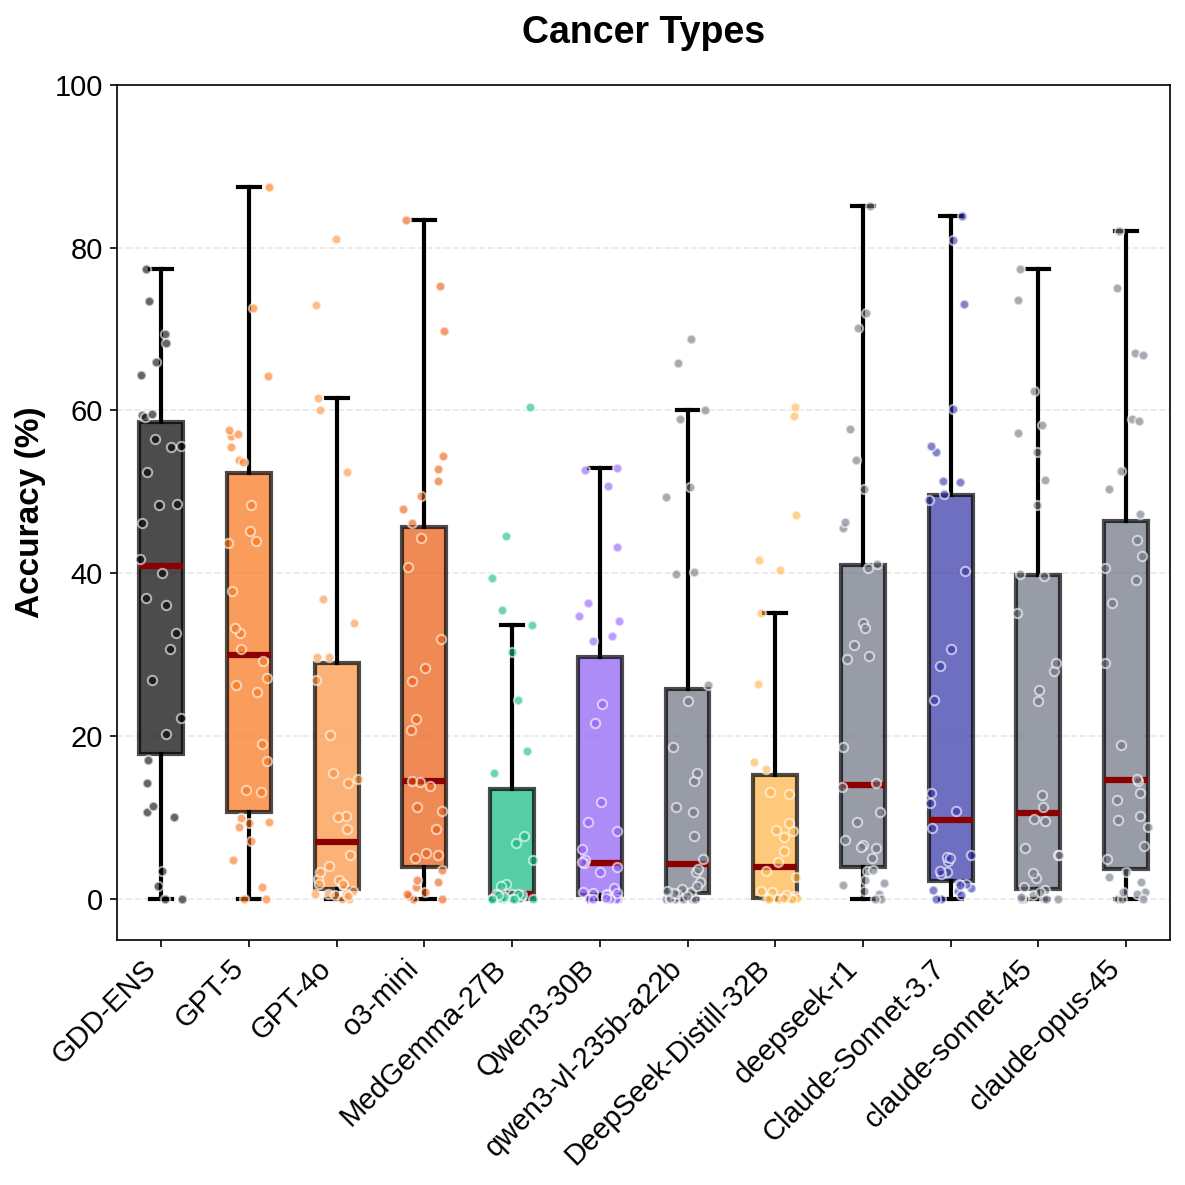

✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/accuracy_boxplot.pdf


In [28]:
# Cell 14: Accuracy Box Plot

print("Creating accuracy box plot...\n")

fig = create_model_boxplot_with_dots(
    metrics_df=accuracy_by_cancer,
    metric_col='accuracy',
    models_to_include=MODEL_NAMES,
    figsize=(8, 8),
    fontsize=14,
    dot_alpha=0.6,
    dot_size=20,
    jitter_strength=0.25,
    title='Cancer Types',
    y_label='Accuracy (%)',
    y_lim=[-5, 100]
)

plt.show()

# Save figure
output_file = os.path.join(OUTPUT_DIR, 'accuracy_boxplot.pdf')
fig.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved to: {output_file}")

Creating F1 score box plot...



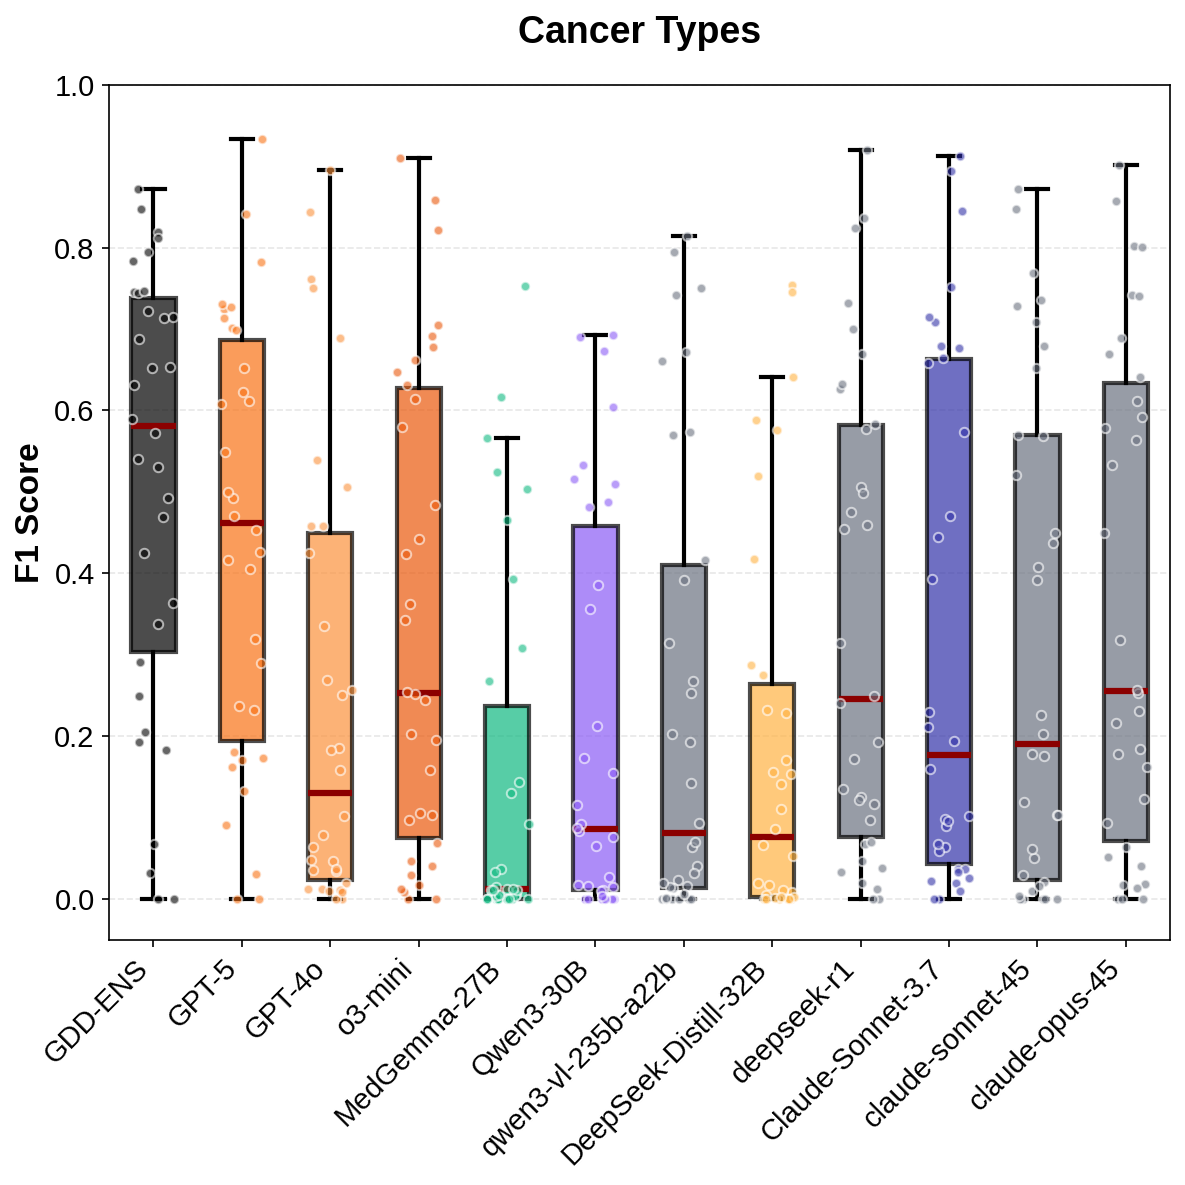

✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/f1_boxplot.pdf


In [29]:
# Cell 15: F1 Score Box Plot

print("Creating F1 score box plot...\n")

fig = create_model_boxplot_with_dots(
    metrics_df=f1_by_cancer,
    metric_col='f1',
    models_to_include=MODEL_NAMES,
    figsize=(8, 8),
    fontsize=14,
    dot_alpha=0.6,
    dot_size=20,
    jitter_strength=0.25,
    title='Cancer Types',
    y_label='F1 Score',
    y_lim=[-0.05, 1]
)

plt.show()

# Save figure
output_file = os.path.join(OUTPUT_DIR, 'f1_boxplot.pdf')
fig.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved to: {output_file}")

Creating precision box plot...



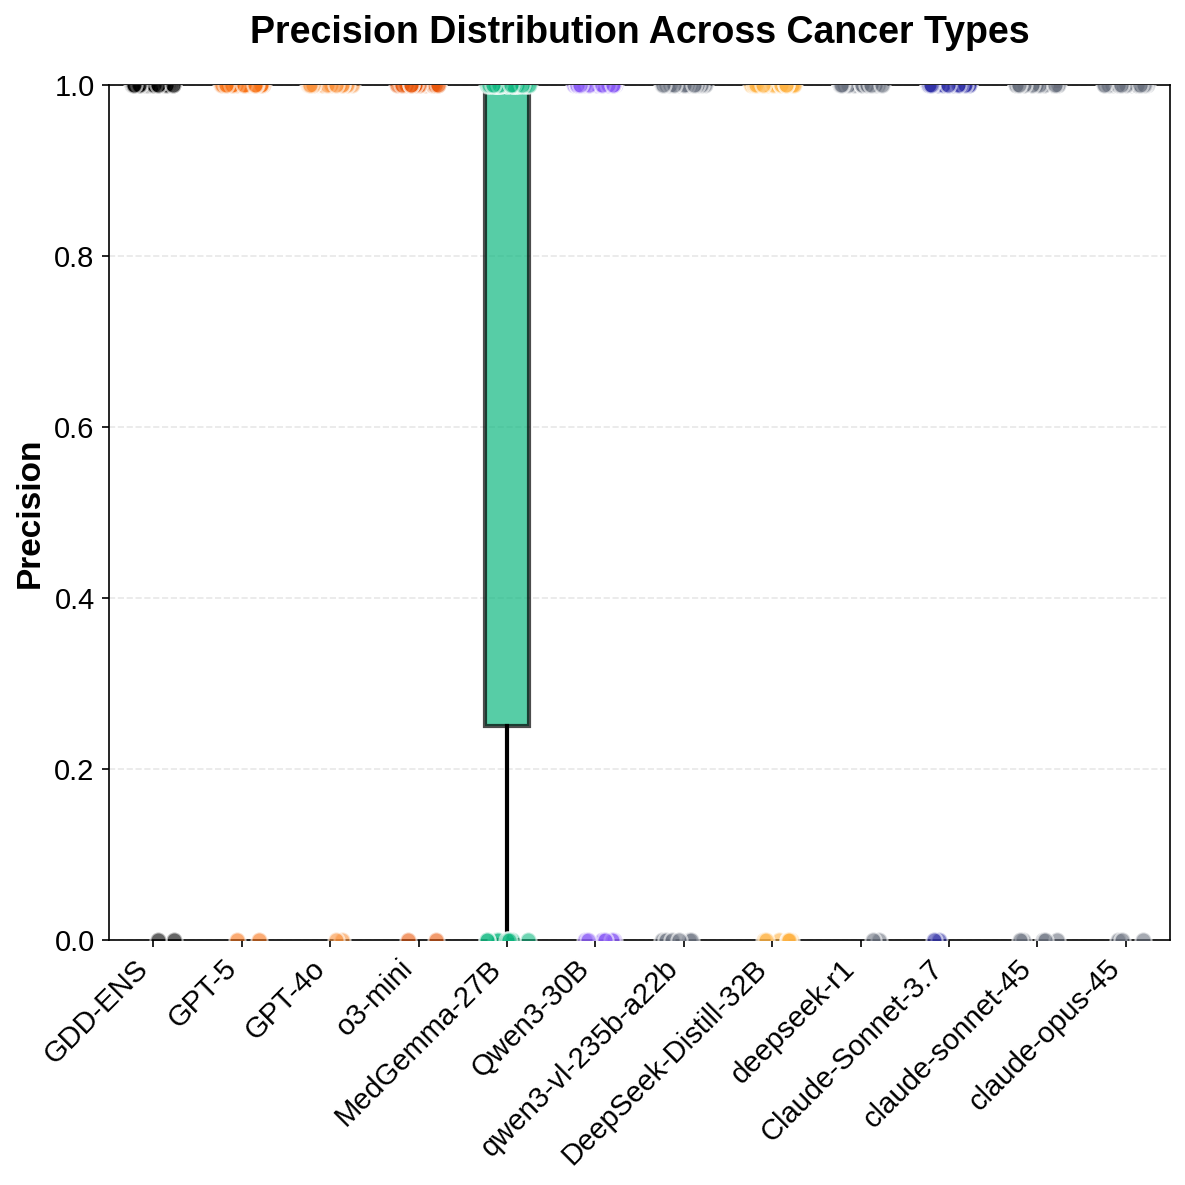

✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/precision_boxplot.pdf


In [30]:
# Cell 16: Precision Box Plot

print("Creating precision box plot...\n")

fig = create_model_boxplot_with_dots(
    metrics_df=precision_by_cancer,
    metric_col='precision',
    models_to_include=MODEL_NAMES,
    figsize=(8, 8),
    fontsize=14,
    dot_alpha=0.6,
    dot_size=60,
    jitter_strength=0.25,
    title='Precision Distribution Across Cancer Types',
    y_label='Precision',
    y_lim=[0, 1]
)

plt.show()

# Save figure
output_file = os.path.join(OUTPUT_DIR, 'precision_boxplot.pdf')
fig.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved to: {output_file}")

Creating recall box plot...



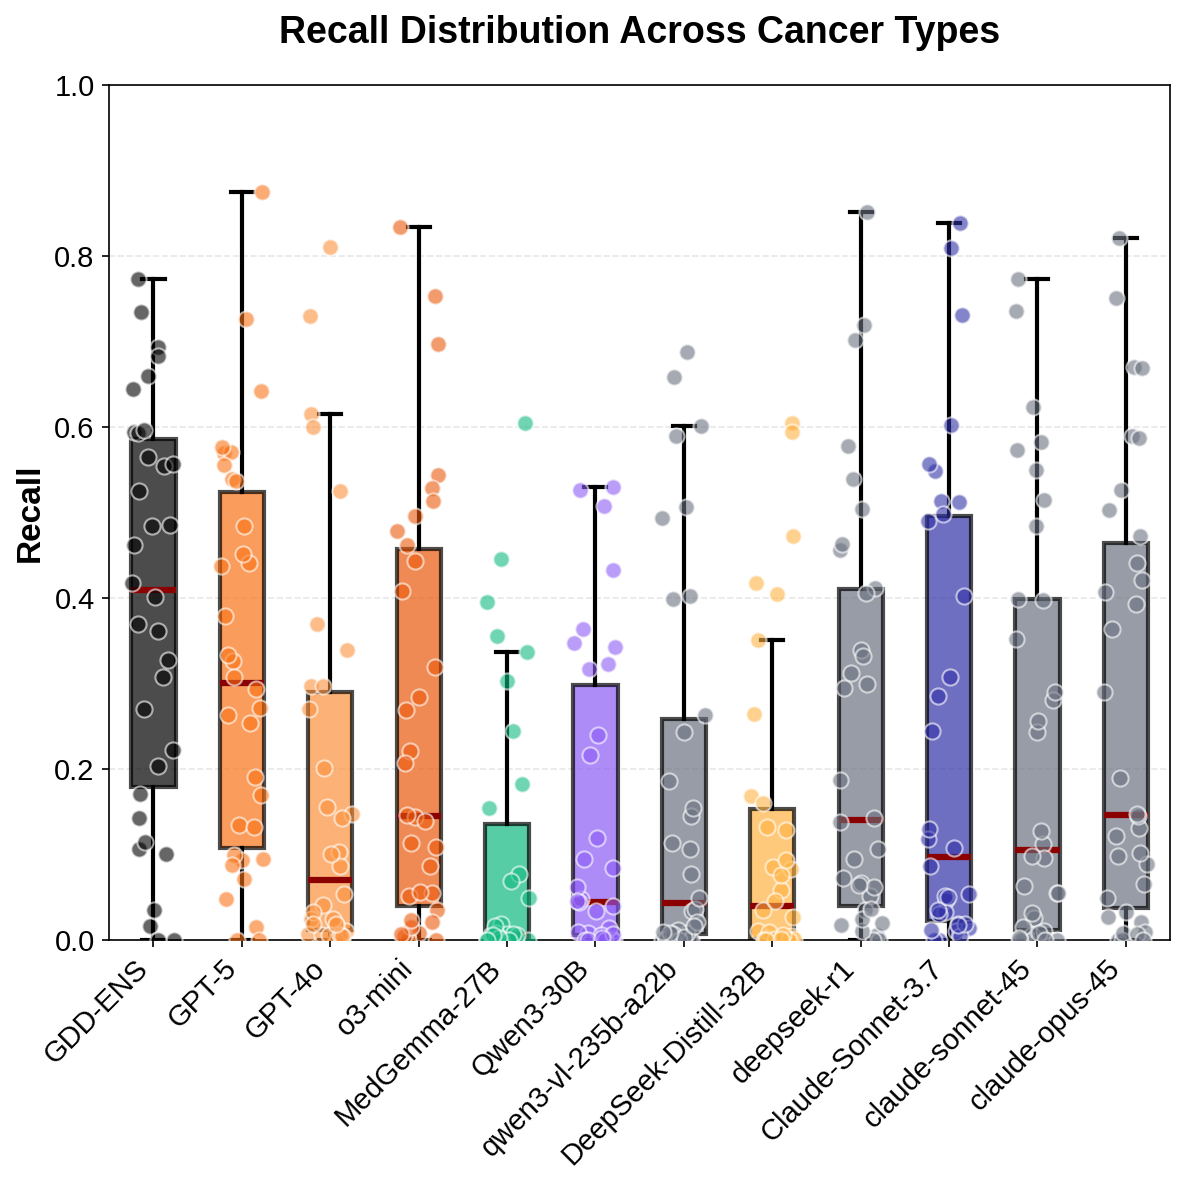

✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/recall_boxplot.pdf


In [31]:
# Cell 17: Recall Box Plot

print("Creating recall box plot...\n")

fig = create_model_boxplot_with_dots(
    metrics_df=recall_by_cancer,
    metric_col='recall',
    models_to_include=MODEL_NAMES,
    figsize=(8, 8),
    fontsize=14,
    dot_alpha=0.6,
    dot_size=60,
    jitter_strength=0.25,
    title='Recall Distribution Across Cancer Types',
    y_label='Recall',
    y_lim=[0, 1]
)

plt.show()

# Save figure
output_file = os.path.join(OUTPUT_DIR, 'recall_boxplot.pdf')
fig.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved to: {output_file}")

Creating overall metrics comparison plot...



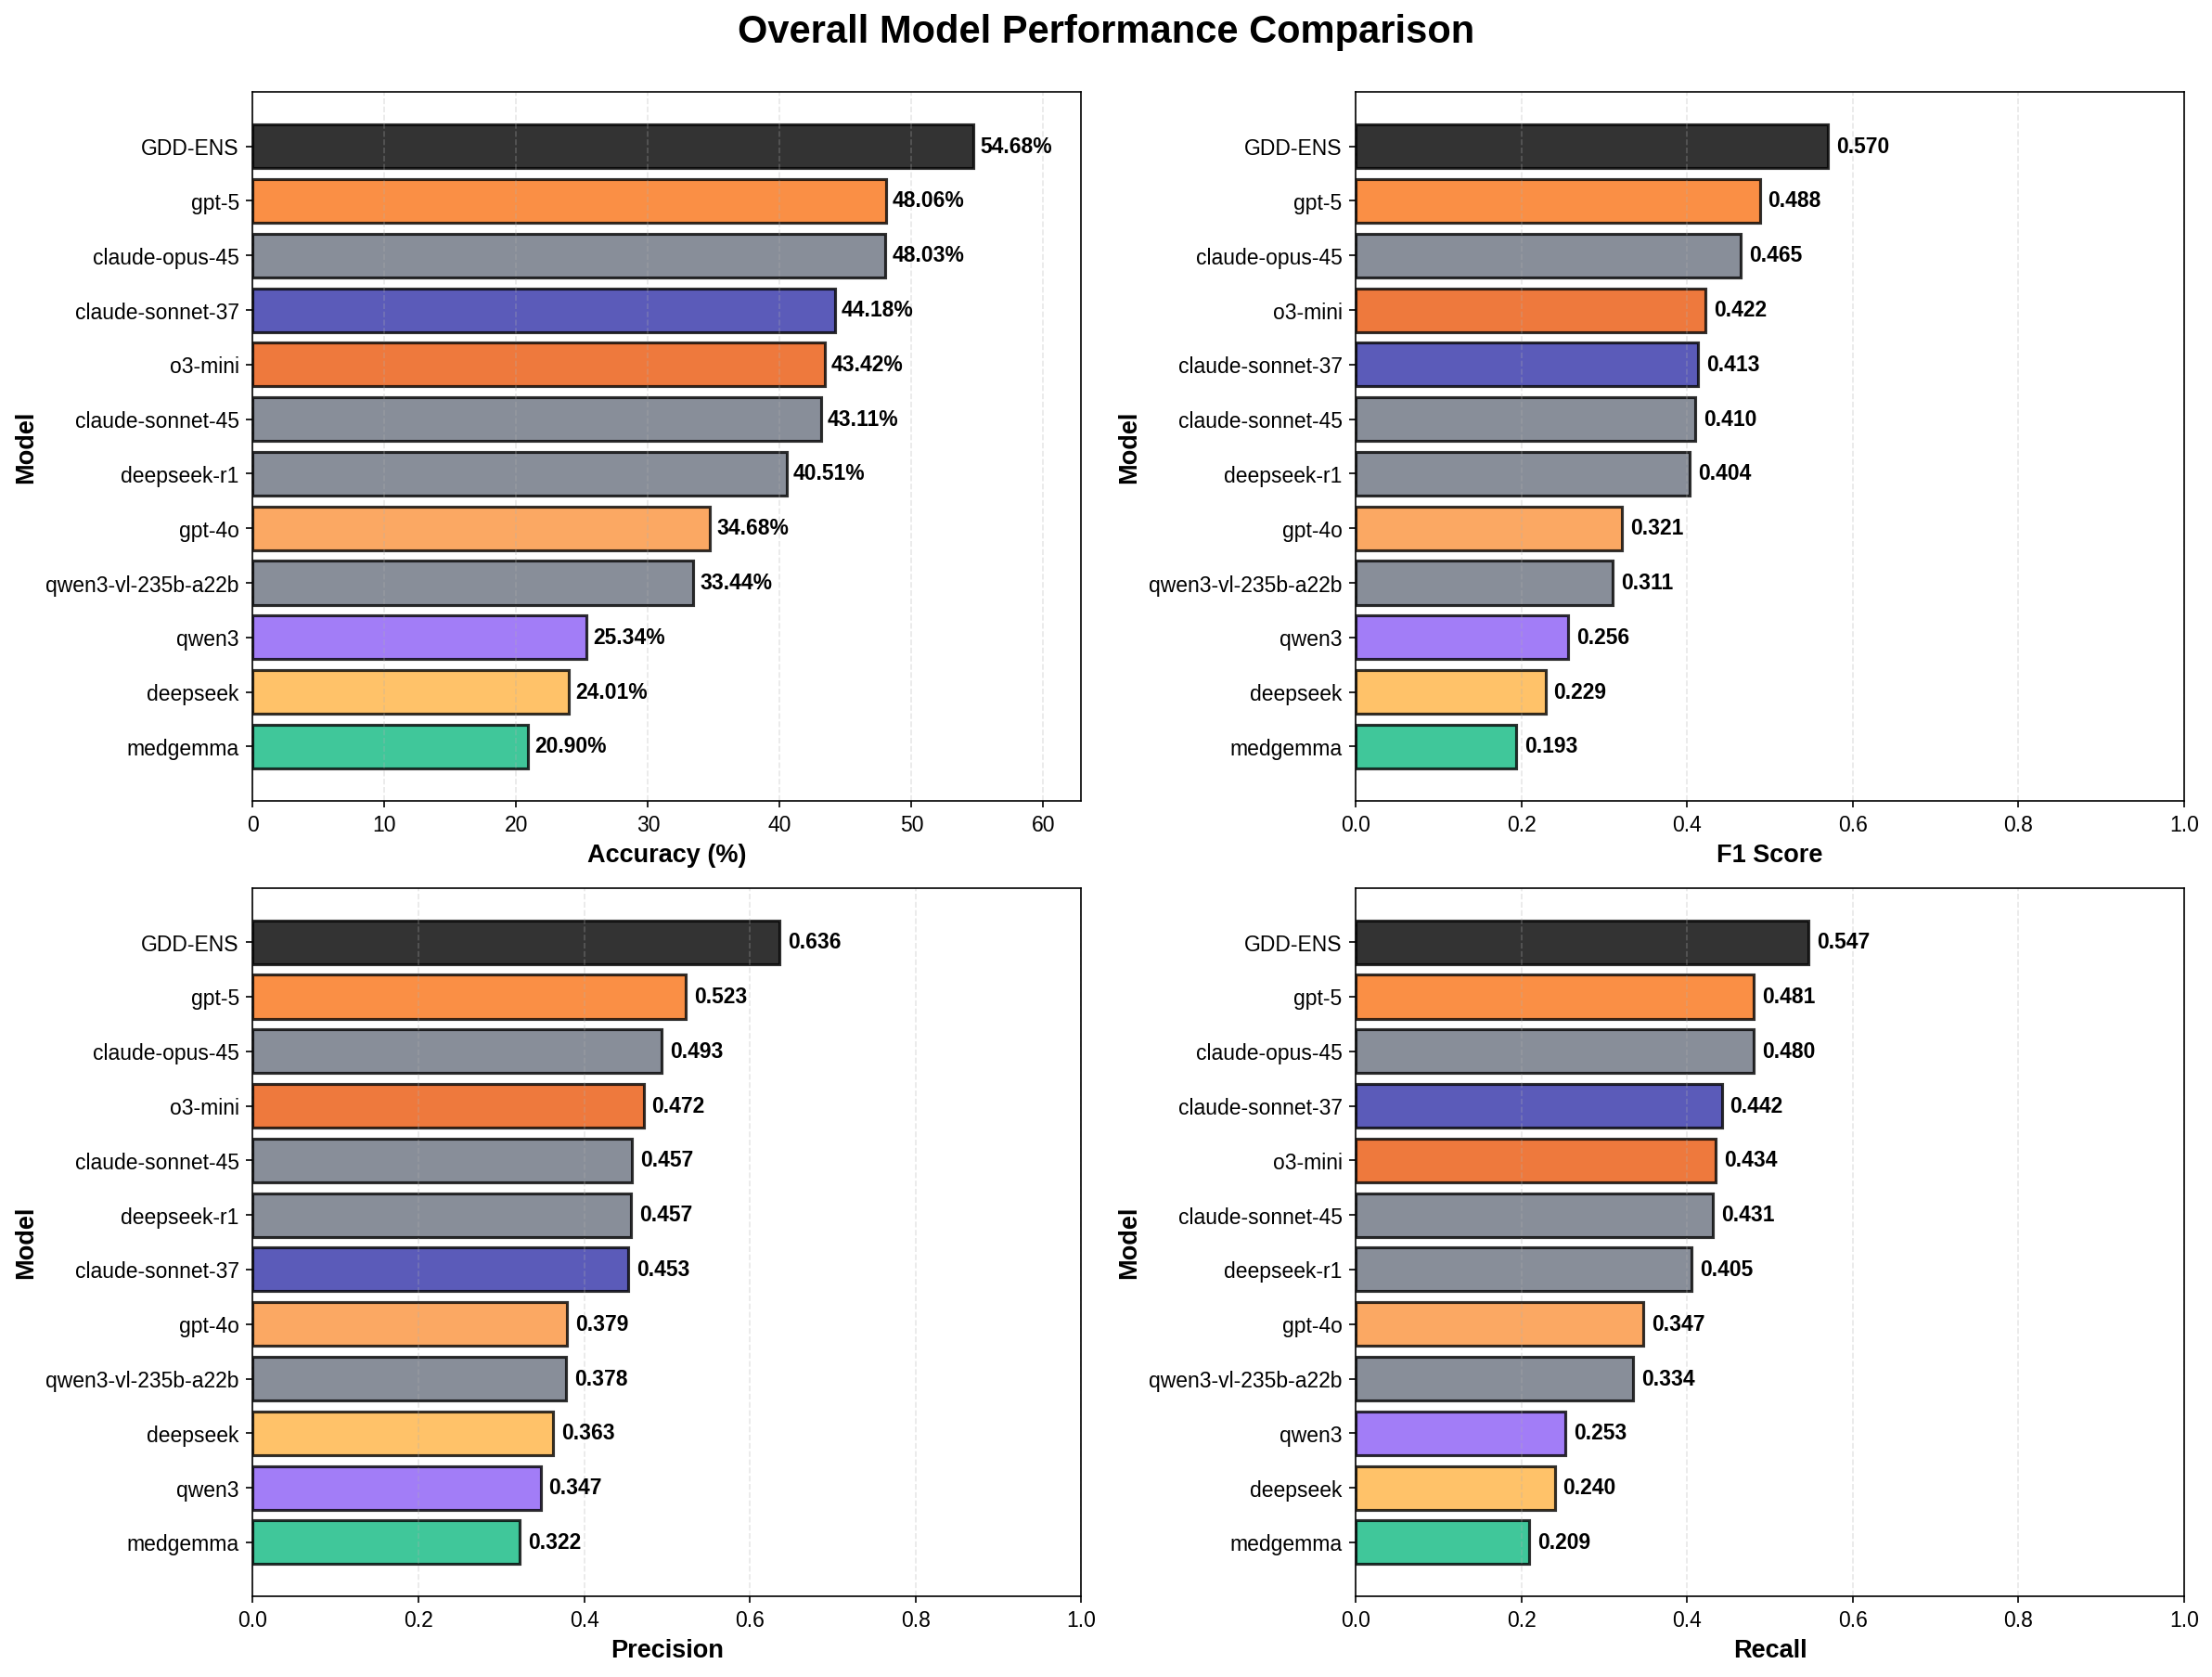

✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/overall_metrics_comparison.png


In [32]:
# Cell 18: Summary Comparison Bar Plot

print("Creating overall metrics comparison plot...\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
fig.suptitle('Overall Model Performance Comparison', fontsize=20, fontweight='bold', y=1.0)

metrics = ['accuracy', 'f1', 'precision', 'recall']
metric_labels = ['Accuracy (%)', 'F1 Score', 'Precision', 'Recall']

# Define colors for models
model_colors = {
    'GDD-ENS': '#000000',
    'claude-sonnet-37': '#3232a8',
    'gpt-5': '#f97316',
    'gpt-4o': '#fb923c',
    'o3-mini': '#ea580c',
    'medgemma': '#10b981',
    'qwen3': '#8b5cf6',
    'deepseek': '#ffb343'
}

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx // 2, idx % 2]
    
    # Sort by metric value
    sorted_metrics = overall_metrics.sort_values(metric, ascending=True)
    
    # Get colors for each model
    colors = [model_colors.get(model, '#6b7280') for model in sorted_metrics['model']]
    
    # Create horizontal bar plot
    bars = ax.barh(sorted_metrics['model'], sorted_metrics[metric], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels - format based on metric type
    for i, (model, value) in enumerate(zip(sorted_metrics['model'], sorted_metrics[metric])):
        if metric == 'accuracy':
            ax.text(value + 0.5, i, f'{value:.2f}%', va='center', fontsize=11, fontweight='bold')
        else:  # f1, precision, recall on 0-1 scale
            ax.text(value + 0.01, i, f'{value:.3f}', va='center', fontsize=11, fontweight='bold')
    
    ax.set_xlabel(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Model', fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Set x-axis limits based on metric type
    if metric == 'accuracy':
        ax.set_xlim(0, max(sorted_metrics[metric]) * 1.15)
    else:  # f1, precision, recall on 0-1 scale
        ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Save figure
output_file = os.path.join(OUTPUT_DIR, 'overall_metrics_comparison.png')
fig.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved to: {output_file}")

Creating per-cancer type performance heatmap...



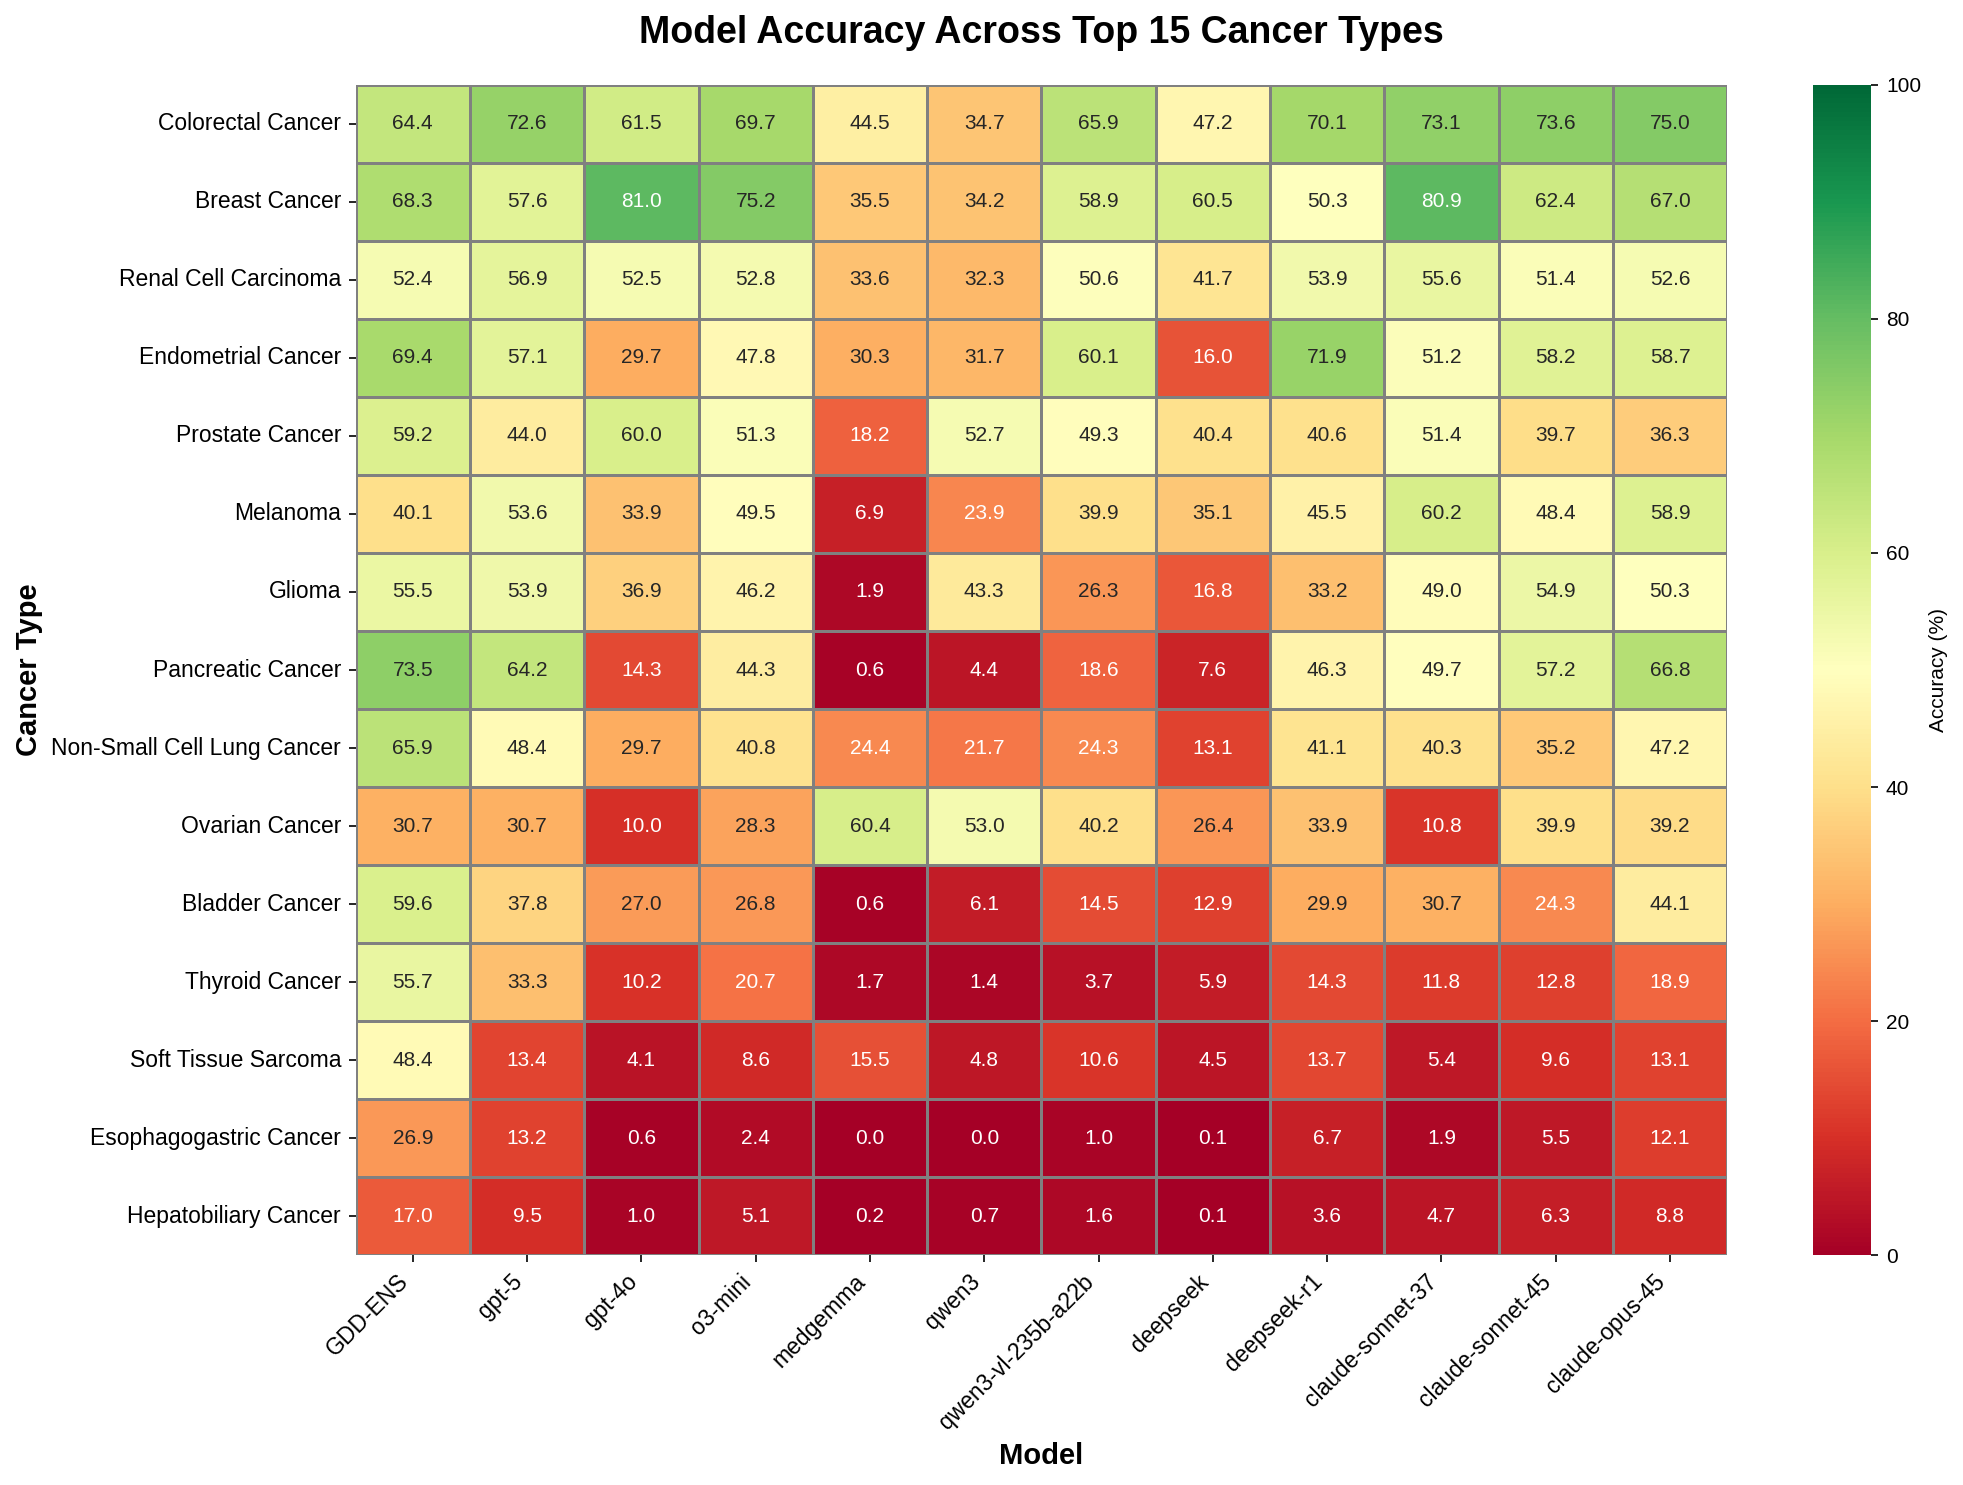

✓ Saved to: /data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/3_cancer_type_classification/accuracy_heatmap_top_cancers.png


In [33]:
# Cell 19: Per-Cancer Type Performance Heatmap

print("Creating per-cancer type performance heatmap...\n")

# Pivot accuracy data for heatmap
pivot_accuracy = accuracy_by_cancer.pivot(index='cancer_type', columns='model', values='accuracy')

# Get top N cancer types by total samples
cancer_samples = accuracy_by_cancer.groupby('cancer_type')['n_samples'].first().sort_values(ascending=False)
top_cancers = cancer_samples.head(TOP_N).index.tolist()
pivot_top = pivot_accuracy.loc[top_cancers]

# Sort by mean accuracy
pivot_top = pivot_top.loc[pivot_top.mean(axis=1).sort_values(ascending=False).index]

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

sns.heatmap(
    pivot_top[MODEL_NAMES],  # Ensure consistent column order
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Accuracy (%)'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

ax.set_title(f'Model Accuracy Across Top {TOP_N} Cancer Types', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Cancer Type', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save figure
output_file = os.path.join(OUTPUT_DIR, 'accuracy_heatmap_top_cancers.png')
fig.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved to: {output_file}")

In [34]:
# Cell 20: Analysis Summary

print("\n" + "=" * 100)
print("ANALYSIS SUMMARY")
print("=" * 100)

print(f"\n1. Dataset Overview:")
print(f"   - Total samples analyzed: {len(df)}")
print(f"   - Number of cancer types: {df['ground_truth'].nunique()}")
print(f"   - Cancer types with ≥{MIN_SAMPLES_PER_CANCER} samples: {accuracy_by_cancer['cancer_type'].nunique()}")

print(f"\n2. Best Overall Performance (by Accuracy):")
best_model = overall_metrics.iloc[0]
print(f"   - Model: {best_model['model']}")
print(f"   - Accuracy: {best_model['accuracy']:.2f}%")
print(f"   - F1 Score: {best_model['f1']:.4f}")
print(f"   - Precision: {best_model['precision']:.4f}")
print(f"   - Recall: {best_model['recall']:.4f}")

print(f"\n3. Performance Range:")
print(f"   - Accuracy: {overall_metrics['accuracy'].min():.2f}% - {overall_metrics['accuracy'].max():.2f}%")
print(f"   - F1 Score: {overall_metrics['f1'].min():.4f} - {overall_metrics['f1'].max():.4f}")
print(f"   - Precision: {overall_metrics['precision'].min():.4f} - {overall_metrics['precision'].max():.4f}")
print(f"   - Recall: {overall_metrics['recall'].min():.4f} - {overall_metrics['recall'].max():.4f}")

print(f"\n4. Per-Cancer Type Performance (Accuracy):")
for model_name in MODEL_NAMES:
    model_data = accuracy_by_cancer[accuracy_by_cancer['model'] == model_name]
    if len(model_data) > 0:
        print(f"   {model_name}:")
        print(f"     - Mean: {model_data['accuracy'].mean():.2f}%")
        print(f"     - Std: {model_data['accuracy'].std():.2f}%")
        print(f"     - Range: {model_data['accuracy'].min():.2f}% - {model_data['accuracy'].max():.2f}%")

print(f"\n5. Output Files Generated:")
print(f"   - {OUTPUT_DIR}/overall_metrics.csv")
print(f"   - {OUTPUT_DIR}/accuracy_by_cancer_type.csv")
print(f"   - {OUTPUT_DIR}/f1_by_cancer_type.csv")
print(f"   - {OUTPUT_DIR}/precision_by_cancer_type.csv")
print(f"   - {OUTPUT_DIR}/recall_by_cancer_type.csv")
print(f"   - {OUTPUT_DIR}/accuracy_boxplot.png")
print(f"   - {OUTPUT_DIR}/f1_boxplot.png")
print(f"   - {OUTPUT_DIR}/precision_boxplot.png")
print(f"   - {OUTPUT_DIR}/recall_boxplot.png")
print(f"   - {OUTPUT_DIR}/overall_metrics_comparison.png")
print(f"   - {OUTPUT_DIR}/accuracy_heatmap_top_cancers.png")

print("\n" + "=" * 100)
print("✓ Analysis complete!")
print("=" * 100)


ANALYSIS SUMMARY

1. Dataset Overview:
   - Total samples analyzed: 102791
   - Number of cancer types: 34
   - Cancer types with ≥10 samples: 34

2. Best Overall Performance (by Accuracy):
   - Model: GDD-ENS
   - Accuracy: 54.68%
   - F1 Score: 0.5702
   - Precision: 0.6361
   - Recall: 0.5468

3. Performance Range:
   - Accuracy: 20.90% - 54.68%
   - F1 Score: 0.1933 - 0.5702
   - Precision: 0.3219 - 0.6361
   - Recall: 0.2090 - 0.5468

4. Per-Cancer Type Performance (Accuracy):
   GDD-ENS:
     - Mean: 38.72%
     - Std: 23.62%
     - Range: 0.00% - 77.33%
   gpt-5:
     - Mean: 32.24%
     - Std: 23.03%
     - Range: 0.00% - 87.47%
   gpt-4o:
     - Mean: 17.83%
     - Std: 23.13%
     - Range: 0.00% - 80.99%
   o3-mini:
     - Mean: 24.91%
     - Std: 24.48%
     - Range: 0.00% - 83.38%
   medgemma:
     - Mean: 9.69%
     - Std: 16.15%
     - Range: 0.00% - 60.39%
   qwen3:
     - Mean: 14.01%
     - Std: 17.89%
     - Range: 0.00% - 52.99%
   qwen3-vl-235b-a22b:
     - Mean: 1